In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [29]:
img=cv2.imread('../Images/lenna.png',cv2.IMREAD_GRAYSCALE)

In [47]:
img.shape

(256, 256)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

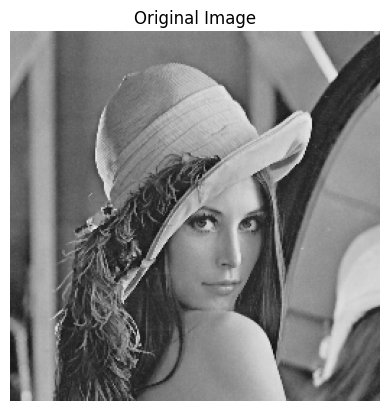

In [30]:
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

In [32]:
def convolution(image, kernel):
 
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate padding
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    
    # Pad the image with zeros
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Initialize output image
    output = np.zeros_like(image, dtype=np.float32)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            # Extract the region of interest
            roi = padded_image[i:i+kernel_height, j:j+kernel_width]
        
            # Apply kernel (element-wise multiplication and sum)
            output[i, j] = np.sum(roi * kernel)
    
    return output

In [ ]:
def normalize(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros_like(image)
    return ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)


# Prewitt Operator Both vertical and horizontal

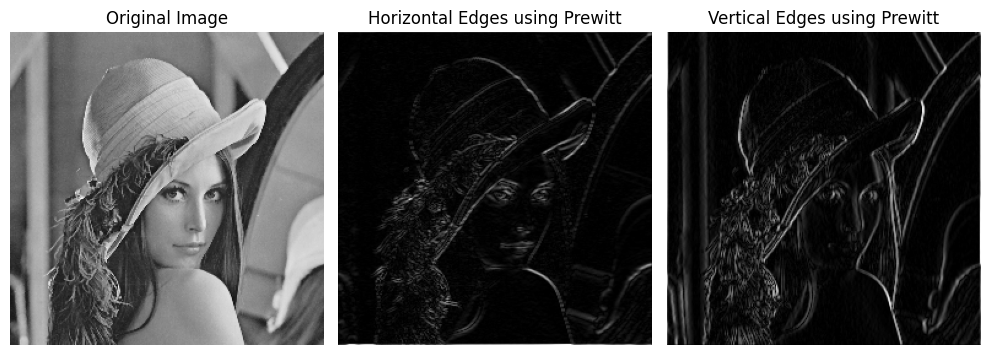

In [ ]:
prewitt_horizontal = np.array([[-1, -1, -1],
                               [0, 0, 0],
                               [1, 1, 1]])

# Prewitt vertical kernel
prewitt_vertical = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])

horizontal_edges = convolution(img, prewitt_horizontal)
vertical_edges = convolution(img, prewitt_vertical)

sobel_horizontal_abs = np.abs(horizontal_edges)
sobel_vertical_abs = np.abs(vertical_edges)

prewitt_horizontal = normalize(sobel_horizontal_abs)
prewitt_vertical = normalize(sobel_vertical_abs)

plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(prewitt_horizontal, cmap='gray')
plt.title('Horizontal Edges using Prewitt')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(prewitt_vertical, cmap='gray')
plt.title('Vertical Edges using Prewitt')
plt.axis('off')


plt.tight_layout()
plt.show()

# Sobel Operator Both vertical and horizontal

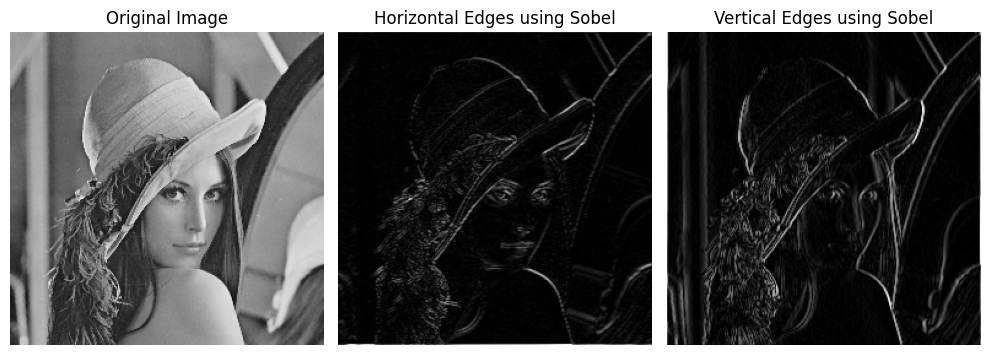

In [ ]:


# Define Sobel kernels again
sobel_horizontal = np.array([[-1, -2, -1],
                             [0, 0, 0],
                             [1, 2, 1]])

sobel_vertical = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

sobel_horizontal_edges = convolution(img, sobel_horizontal)
sobel_vertical_edges = convolution(img, sobel_vertical)

sobel_horizontal_abs = np.abs(sobel_horizontal_edges)
sobel_vertical_abs = np.abs(sobel_vertical_edges)

sobel_horizontal = normalize(sobel_horizontal_abs)
sobel_vertical = normalize(sobel_vertical_abs)


plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_horizontal, cmap='gray')
plt.title('Horizontal Edges using Sobel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_vertical, cmap='gray')
plt.title('Vertical Edges using Sobel')
plt.axis('off')

plt.tight_layout()
plt.show()

# Canny Edge Detection

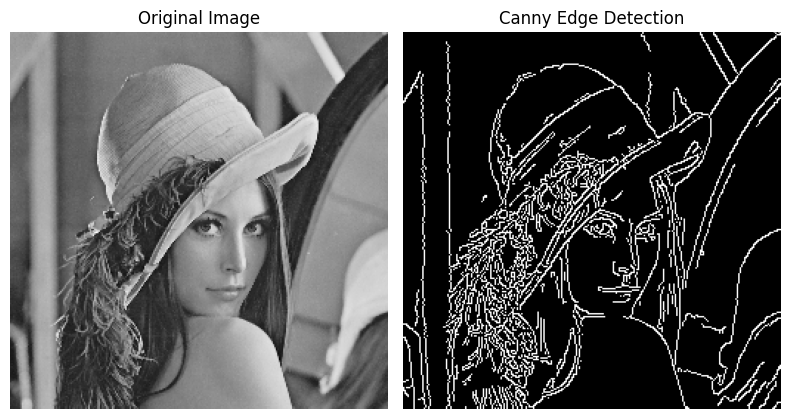

In [ ]:

edge = cv2.Canny(img, 80, 160)


plt.figure(figsize=(8,5 ))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edge, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()